In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("20241107_management_insight_personalization_context.json", "r") as fp:
    personalization_context = json.load(fp)

In [11]:
encoding_evolution = {group: np.array([
    [response["encoding"] 
     for response in personalization_context["responseStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Treatment", "Control"]}

In [4]:
encoding_evolution.shape

(37, 11, 15)

In [5]:
hyperparameterLevels = {
    "exclude": [
      "[\"num__weekday\"]",
      "[\"num__windspeed\", \"num__weekday\"]",
      "[\"num__windspeed\"]",
      "[]"
    ],
    "interactions": [
      "1",
      "2",
      "3"
    ],
    "max_bins": [
      "8",
      "16",
      "256"
    ],
    "min_samples_leaf": [
      "64"
    ],
    "monotonicity_constraints": [
      "[\"num__atemp\", \"num__windspeed\"]",
      "[\"num__atemp\"]",
      "[\"num__windspeed\"]",
      "[]"
    ]
}

In [12]:
def plot_distribution(evolution, stack_pos: int):
    for i, (parameter_name, levels) in enumerate(hyperparameterLevels.items()):
        offset = sum([len(hyperparameterLevels[hp]) for hp in list(hyperparameterLevels.keys())[:i]])
        labels = [f"{parameter_name}: {l}" for l in levels]
        plt.bar(x = labels, height=evolution[:,stack_pos,:].sum(axis=0)[offset:offset+len(levels)])
        plt.xticks(rotation=90)

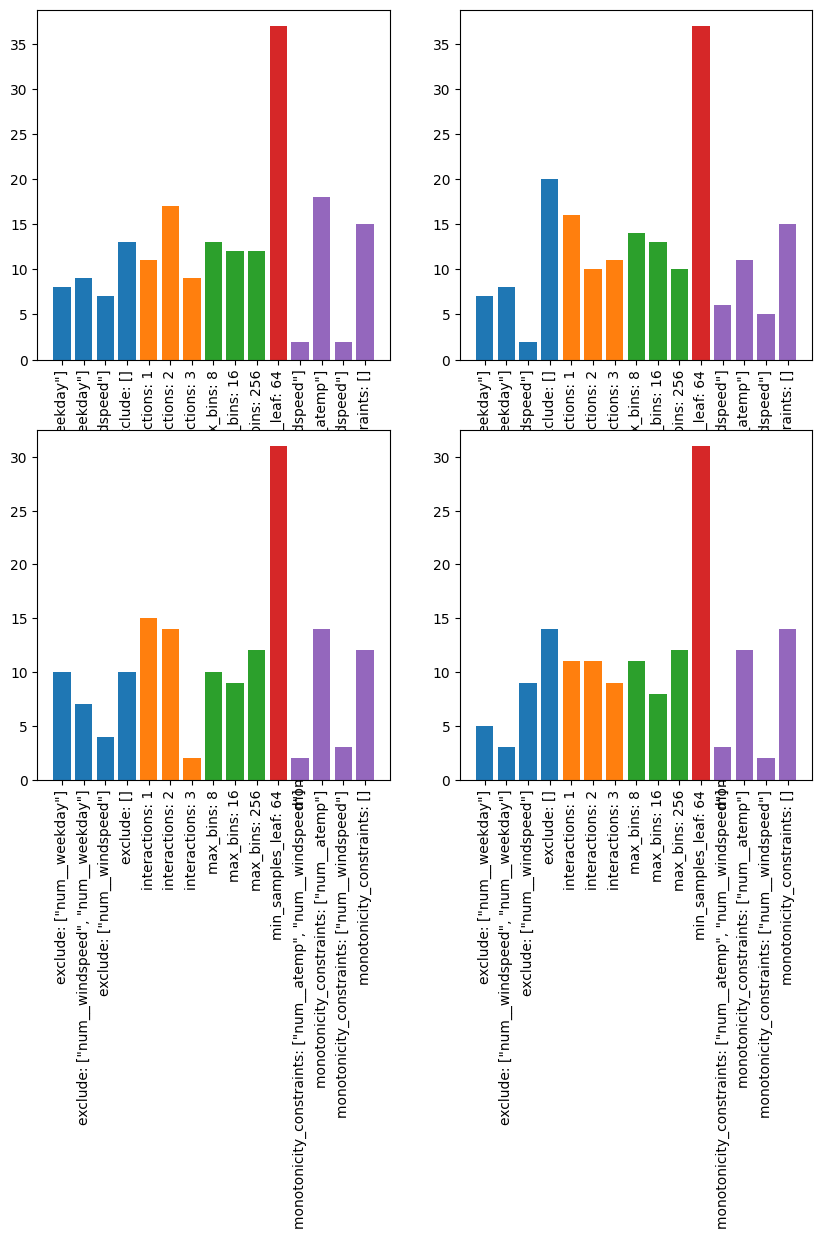

In [16]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plot_distribution(encoding_evolution["Treatment"], -1)
plt.subplot(2,2,2)
plot_distribution(encoding_evolution["Treatment"], 0)
plt.subplot(2,2,3)
plot_distribution(encoding_evolution["Control"], -1)
plt.subplot(2,2,4)
plot_distribution(encoding_evolution["Control"], 0)


In [74]:
reward_evolution = {group: np.array([
    [int(response["reward"])
     for response in personalization_context["requestStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Treatment", "Control"]}

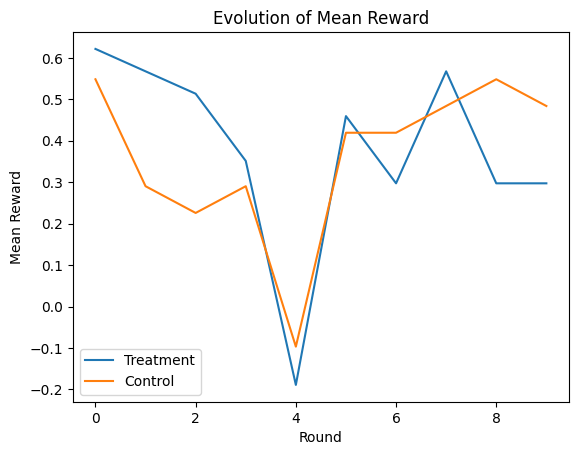

In [190]:
# how do the mean rewards evolve over the rounds?

plt.title("Evolution of Mean Reward")
plt.plot(reward_evolution["Treatment"].mean(axis=0)[::-1])
plt.plot(reward_evolution["Control"].mean(axis=0)[::-1])
plt.xlabel("Round")
plt.ylabel("Mean Reward")
plt.legend(["Treatment", "Control"])

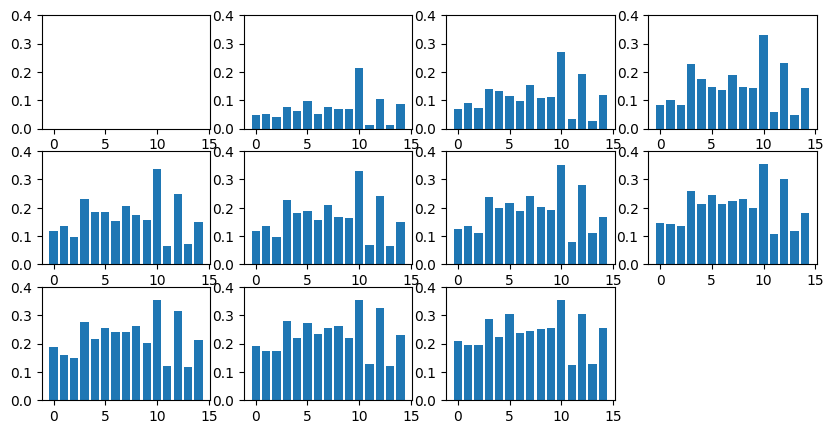

In [189]:
# how does the mean absolute value of the reward model's weights evolve?

mu_evolution = {group: np.array([
    [response["userContext"]["mu"]
     for response in personalization_context["responseStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Treatment", "Control"]}

plt.figure(figsize=(10,5))
# create plot for every personalization round
for i in range(11):
    plt.subplot(3,4,i+1)
    plt.ylim(0,0.4)
    plt.bar(range(15), height = np.absolute(mu_evolution["Treatment"]).mean(axis=0)[-(i+1),:])

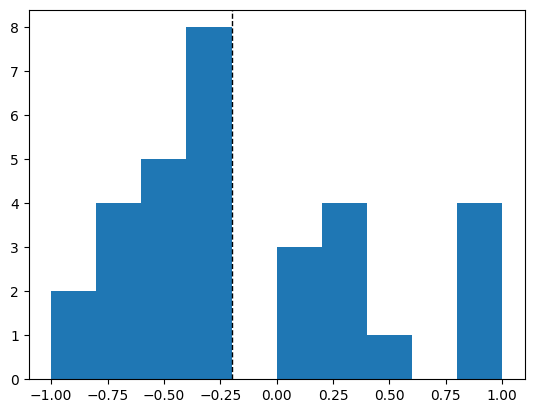

In [187]:
# reward calibration - how do we need so set the reward so that there users rate (approx.) 50% of dashboards as good / bad

control_userinput_evolution = np.array([
    [1 if int(response["userInput"]) >= 6 else -1
     for response in personalization_context["requestStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == "Control"])

# mean over rounds -> every datum corresponds to the mean for a user
plt.hist(np.mean(control_userinput_evolution, axis=1))
plt.axvline(np.median(np.mean(control_userinput_evolution, axis=1)), color='k', linestyle='dashed', linewidth=1)

(array([ 1.,  0.,  4.,  1.,  0.,  5.,  7.,  3.,  0., 10.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

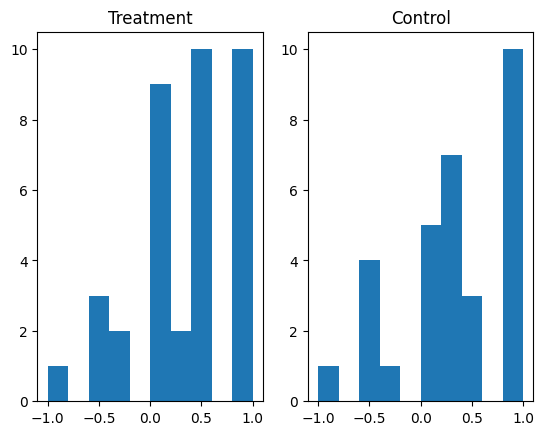

In [186]:
reward_evolution = {group: np.array([
    [int(response["reward"])
     for response in personalization_context["requestStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Control", "Treatment"]}

plt.subplot(1,2,1)
plt.title("Treatment")
# mean over rounds -> every datum corresponds to the mean for a user
plt.hist(control_evolution["Treatment"].mean(axis=1))
plt.subplot(1,2,2)
plt.title("Control")
# mean over rounds -> every datum corresponds to the mean for a user
plt.hist(control_evolution["Control"].mean(axis=1))

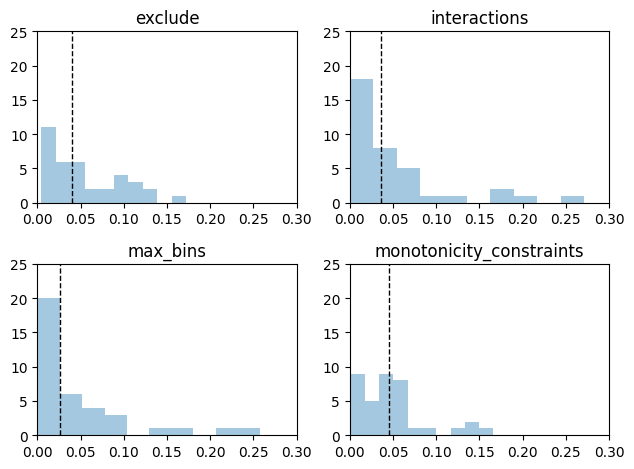

In [176]:
# hyperparameter variance - do we learn differences between hyperparameter levels?

def hyperparameter_variance(evolution, stack_pos: int):
    variances = {}
    for i, (parameter_name, levels) in enumerate(hyperparameterLevels.items()):
        offset = sum([len(hyperparameterLevels[hp]) for hp in list(hyperparameterLevels.keys())[:i]])
        labels = [f"{parameter_name}: {l}" for l in levels]
        variances[parameter_name] = evolution[:,stack_pos,offset:offset+len(levels)].var(axis=1)
    return variances   

variances = hyperparameter_variance(mu_evolution["Treatment"], 0)
hyperparameters = ["exclude", "interactions", "max_bins", "monotonicity_constraints"]
for i, hyperparameter in enumerate(hyperparameters):
    plt.subplot(2,2,i+1)
    plt.title(hyperparameter)
    plt.xlim(0,0.3)
    plt.ylim(0,25)
    plt.hist(variances[hyperparameter], alpha=0.4)
    plt.axvline(np.median(variances[hyperparameter]), color='k', linestyle='dashed', linewidth=1)
plt.tight_layout()